In [1]:
import os
import sys
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
from ase.io import read

# Add the parent directory to sys.path for module imports
# TODO: Better imports
sys.path.insert(0, "..")
import vis_utils
sys.path.insert(0, "../..")
from data import make_nerfstudio_format, make_tomo_projections
from baselines import classical_baselines

%load_ext autoreload
%autoreload 2

In [2]:
nanoparticle = 'Au'
atoms_path = f'../../data/structures/{nanoparticle}_NP.xyz'

### Simulate projections

In [3]:
# Simulate projections
atoms = read(atoms_path)
angles = np.linspace(-90, 90, 181)
projections = make_tomo_projections.make_tomo_projections(atoms_path, angles)

181it [05:18,  1.76s/it]


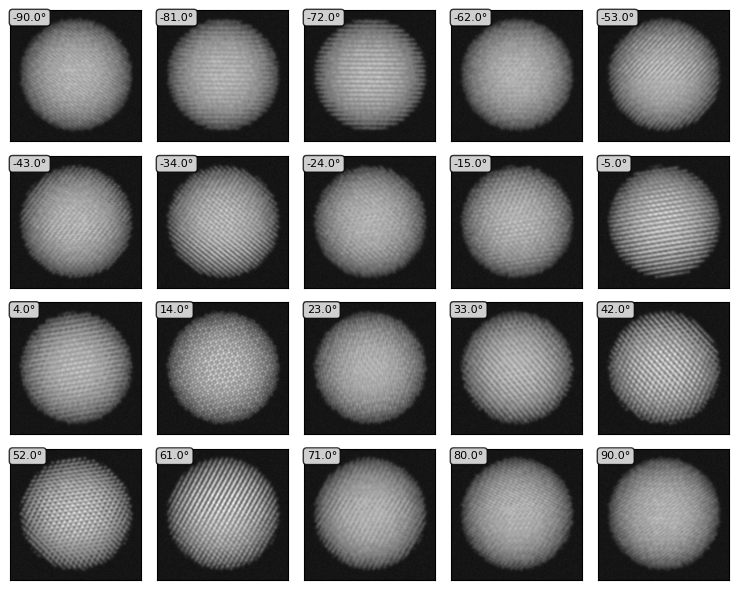

In [4]:
proj_fig = vis_utils.plot_projections(projections, angles)

In [5]:
# Write projections in nerfstudio format
output_data_path = f'sim_{nanoparticle}_NP_fulldata'
make_nerfstudio_format.write_nerfstudio_format_from_proj_array(projections, angles, output_data_path)

print(f"Nerfstudio format data written to: {output_data_path}")

Nerfstudio format data written to: sim_Au_NP_fulldata


### Train Gaussian Splatting Model

In [6]:
cmd = f'ns-train splatfacto --data {output_data_path} --viewer.quit_on_train_completion True'
_ = os.system(cmd)

/home/nmsingh/miniconda3/envs/nerfstudio/lib/python3.8/site-packages/tinycudann/modules.py:57: UserWarning: tinycudann was built for lower compute capability (61) than the system's (86). Performance may be suboptimal.
  warnings.warn(f"tinycudann was built for lower compute capability ({cc}) than the system's ({system_compute_capability}). Performance may be suboptimal.")


[14:25:46] Using --data alias for --data.pipeline.datamanager.data                                          ]8;id=643252;file:///home/nmsingh/dev/gaussian_atoms/nerfstudio/nerfstudio/scripts/train.py\train.py]8;;\:]8;id=102049;file:///home/nmsingh/dev/gaussian_atoms/nerfstudio/nerfstudio/scripts/train.py#230\230]8;;\
──────────────────────────────────────────────────────── Config ────────────────────────────────────────────────────────
TrainerConfig(
    _target=<class 'nerfstudio.engine.trainer.Trainer'>,
    output_dir=PosixPath('outputs'),
    method_name='splatfacto',
    experiment_name=None,
    project_name='nerfstudio-project',
    timestamp='2025-10-28_142546',
    machine=MachineConfig(seed=42, num_devices=1, num_machines=1, machine_rank=0, dist_url='auto', device_type='cuda'),
    logging=LoggingConfig(
        relative_log_dir=PosixPath('.'),
        steps_per_log=10,
        max_buffer_size=20,
        local_writer=LocalWriterConfig(
            _target=<class 'ner

/home/nmsingh/dev/gaussian_atoms/nerfstudio/nerfstudio/models/splatfacto.py:258: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  features_dc = torch.tensor(torch.ones(num_points, 3))
/home/nmsingh/dev/gaussian_atoms/nerfstudio/nerfstudio/models/splatfacto.py:259: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  features_rest = torch.tensor(torch.zeros((num_points, dim_sh - 1, 3)))
/home/nmsingh/miniconda3/envs/nerfstudio/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nmsingh/miniconda3/envs/nerfstudio/lib/python3.8/site-packages

╭─────────────── viser ───────────────╮
│             ╷                       │
│   HTTP      │ http://0.0.0.0:7007   │
│   Websocket │ ws://0.0.0.0:7007     │
│             ╵                       │
╰─────────────────────────────────────╯
(viser) Connection opened (0, 1 total), 50 persistent messages
[14:25:49] Caching / undistorting eval images                                             ]8;id=529903;file:///home/nmsingh/dev/gaussian_atoms/nerfstudio/nerfstudio/data/datamanagers/full_images_datamanager.py\full_images_datamanager.py]8;;\:]8;id=631262;file:///home/nmsingh/dev/gaussian_atoms/nerfstudio/nerfstudio/data/datamanagers/full_images_datamanager.py#230\230]8;;\
Caching / undistorting eval images ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00
[NOTE] Not running eval iterations since only viewer is enabled.
Use --vis {wandb, tensorboard, viewer+wandb, viewer+tensorboard} to run with eval.
No Nerfstudio checkpoint to load, so training from scratch.
Disabled comet/tensorboar

/home/nmsingh/miniconda3/envs/nerfstudio/lib/python3.8/site-packages/torch/_inductor/compile_fx.py:135: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


[14:26:11] Caching / undistorting train images                                            ]8;id=735392;file:///home/nmsingh/dev/gaussian_atoms/nerfstudio/nerfstudio/data/datamanagers/full_images_datamanager.py\full_images_datamanager.py]8;;\:]8;id=571412;file:///home/nmsingh/dev/gaussian_atoms/nerfstudio/nerfstudio/data/datamanagers/full_images_datamanager.py#230\230]8;;\
Caching / undistorting train images ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00m -:--:--
           Printing max of 10 lines. Set flag --logging.local-writer.max-log-size=0 to disable line        ]8;id=911527;file:///home/nmsingh/dev/gaussian_atoms/nerfstudio/nerfstudio/utils/writer.py\writer.py]8;;\:]8;id=6814;file:///home/nmsingh/dev/gaussian_atoms/nerfstudio/nerfstudio/utils/writer.py#448\448]8;;\
           wrapping.                                                                                                    
Step (% Done)       Vis Rays / Sec       Train Iter (time)    ETA (time)           

### Load Gaussian Splatting Results

In [7]:
gs_path = os.path.join('outputs', output_data_path, 'splatfacto')
subfolders = [f for f in os.listdir(gs_path) if os.path.isdir(os.path.join(gs_path, f))]
first_subfolder = max(subfolders, key=lambda x: os.path.getmtime(os.path.join(gs_path, x))) if subfolders else None
gs_path = os.path.join(gs_path, first_subfolder)
true_positions, species, gauss_means, opacities, scales, extent = vis_utils.load_data(gs_path, atoms_path, ckpt=None, flip_yz=True, threshold=True, opacity_threshold=5, load_potential=False)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/home/nmsingh/dev/gaussian_atoms/nerfstudio/nerfstudio/models/splatfacto.py:258: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  features_dc = torch.tensor(torch.ones(num_points, 3))
/home/nmsingh/dev/gaussian_atoms/nerfstudio/nerfstudio/models/splatfacto.py:259: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  features_rest = torch.tensor(torch.zeros((num_points, dim_sh - 1, 3)))
/home/nmsingh/miniconda3/envs/nerfstudio/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nmsingh/miniconda3/envs/nerfstudio/lib/python3.8/site-packages

### Load and Compare Reconstructions

In [8]:
# Get GS reconstruction
model = vis_utils.load_splatfacto_model(gs_path)
gs_recon = vis_utils.get_recon(model, output_data_path)


/home/nmsingh/dev/gaussian_atoms/nerfstudio/nerfstudio/models/splatfacto.py:258: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  features_dc = torch.tensor(torch.ones(num_points, 3))
/home/nmsingh/dev/gaussian_atoms/nerfstudio/nerfstudio/models/splatfacto.py:259: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  features_rest = torch.tensor(torch.zeros((num_points, dim_sh - 1, 3)))
/home/nmsingh/miniconda3/envs/nerfstudio/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nmsingh/miniconda3/envs/nerfstudio/lib/python3.8/site-packages

In [9]:
# Get classical reconstructions
fbp_recon = classical_baselines.reconstruct_3d(projections, angles, recon_type='fbp')
sart_recon = classical_baselines.reconstruct_3d(projections, angles, recon_type='sart')

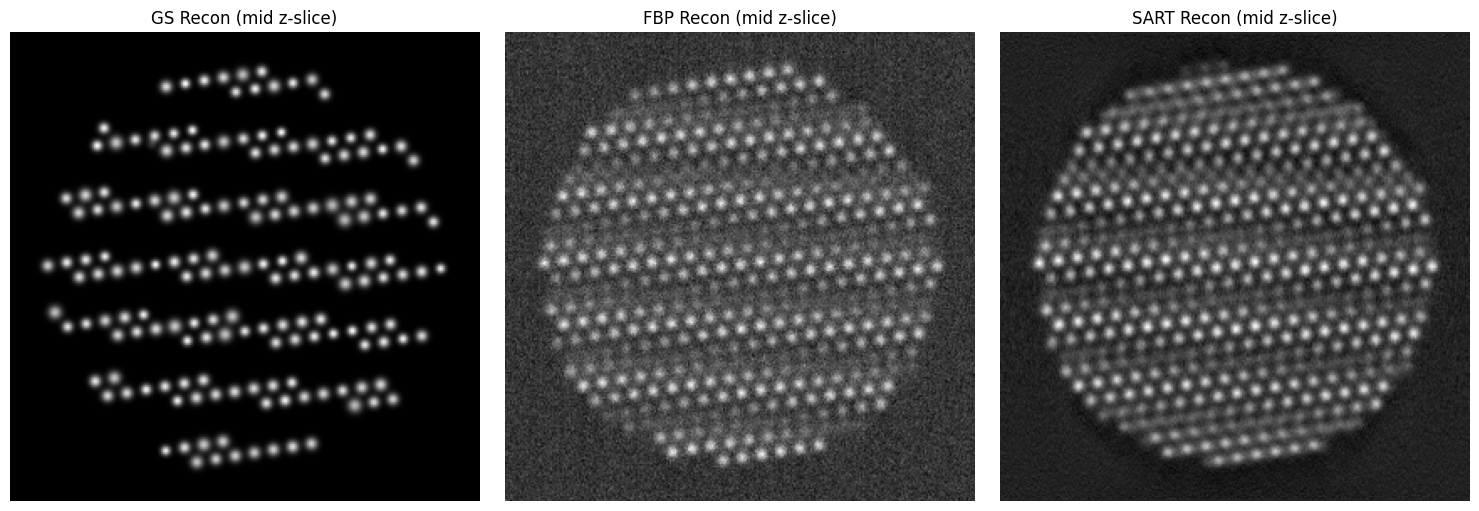

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

mid_slice = gs_recon.shape[2] // 2
mid_slice_fbp = fbp_recon.shape[2] // 2
mid_slice_sart = sart_recon.shape[2] // 2

axs[0].imshow(np.rot90(np.sum(gs_recon[:,:,mid_slice-2:mid_slice+2], axis=2),k=2), cmap='gray')
axs[0].set_title('GS Recon (mid z-slice)')
axs[0].axis('off')

axs[1].imshow(fbp_recon[mid_slice_fbp, :, :], cmap='gray')
axs[1].set_title('FBP Recon (mid z-slice)')
axs[1].axis('off')

axs[2].imshow(sart_recon[mid_slice_sart, :, :], cmap='gray')
axs[2].set_title('SART Recon (mid z-slice)')
axs[2].axis('off')

plt.tight_layout()
plt.show()